In [67]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils import utils

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [68]:
from sklearn.metrics import precision_recall_curve, auc, roc_curve

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 28, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 10})
plt.rcParams.update({"axes.prop_cycle": plt.cycler("color", ["royalblue", "tomato", "forestgreen", "darkgoldenrod", "darkorchid"])})

In [69]:
exp_list = ["glori","m6ace","miclip2","sac"]
exp_dict = {}
exp_path = "/extdata3/baeklab/Jungmin/RNAmod/valid.new/cmp/{exp}.txt"
for exp in exp_list:
    df = pd.read_csv(exp_path.format(exp=exp), sep="\t")
    df["genome_id"] = df["chr"] + ":" + df["str"].astype(str) + ":" + df["pos"].astype(str)
    if "qval_neg" in df.columns:
        df["m6a"] = (df["qval"] < 1E-7) & ~(df["qval_neg"] < 0.1)
    else:
        df["m6a"] = df["qval"] < 1E-7
    exp_dict[exp] = df
for exp in ["m6ace","miclip2","sac"]:
    df = exp_dict[exp]
    df = df.rename(columns={"m6a": f"label_{exp}", "depth": f"depth_{exp}", "qval": f"q_{exp}"})
    df = df[["genome_id", f"label_{exp}", f"depth_{exp}", f"q_{exp}"]].copy()
    exp_dict[exp] = df
for exp in ["glori"]:
    df = exp_dict[exp]
    df = df.rename(columns={"m6a": f"label_{exp}", "depth": f"depth_{exp}", "dom": f"dom_{exp}", "qval": f"q_{exp}"})
    df = df[["genome_id", f"label_{exp}", f"depth_{exp}", f"dom_{exp}", f"q_{exp}"]].copy()
    exp_dict[exp] = df
for exp in exp_list:
    df = exp_dict[exp]
    df = df.set_index("genome_id", drop=True)
    exp_dict[exp] = df

label_df = pd.concat(exp_dict.values(), axis=1).reset_index()
label_df["label_glori_alt"] = (label_df["dom_glori"] >= 0.1) * label_df["label_glori"]
print(label_df)


                genome_id label_glori  depth_glori  dom_glori   q_glori  \
0            chr1:+:14120       False          1.0        NaN  0.129512   
1            chr1:+:63441       False          1.0        NaN  0.137144   
2           chr1:+:183817       False          3.0        NaN  0.016432   
3           chr1:+:184515       False          2.0        NaN  0.381221   
4           chr1:+:184761       False          1.0        NaN  0.194671   
...                   ...         ...          ...        ...       ...   
12206697  chrY:-:57015831         NaN          NaN        NaN       NaN   
12206698  chrY:-:57015855         NaN          NaN        NaN       NaN   
12206699  chrY:-:57015886         NaN          NaN        NaN       NaN   
12206700  chrY:-:57015896         NaN          NaN        NaN       NaN   
12206701  chrY:-:57015923         NaN          NaN        NaN       NaN   

         label_m6ace  depth_m6ace  q_m6ace label_miclip2  depth_miclip2  \
0                NaN    

In [70]:
benchmark_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/poster/benchmark_df.pkl")

In [71]:
benchmark_df = benchmark_df.merge(label_df, on="genome_id", how="inner")
print(benchmark_df)

                genome_id      pm6a       dom  count_all  pred_dorado  \
0         chr10:+:1000681 -0.000000  0.004642      495.0     0.008457   
1         chr10:+:1000683  0.016154  0.013023      501.0     0.002024   
2         chr10:+:1000685 -0.000000  0.007298      501.0     0.017241   
3         chr10:+:1000694 -0.000000  0.006251      509.0     0.006061   
4         chr10:+:1000701  0.023575  0.007125      498.0     0.002083   
...                   ...       ...       ...        ...          ...   
10830114   chrY:-:5337902       NaN       NaN        NaN     0.000000   
10830115   chrY:-:5337903       NaN       NaN        NaN     0.000000   
10830116   chrY:-:5337907       NaN       NaN        NaN          NaN   
10830117   chrY:-:5337909       NaN       NaN        NaN          NaN   
10830118   chrY:-:5337910       NaN       NaN        NaN          NaN   

          count_dorado  pred_m6anet  dom_m6anet  count_m6anet  depth  ...  \
0                473.0          NaN         Na

In [72]:
benchmark_df["label_sum"] = benchmark_df[["label_glori", "label_m6ace", "label_miclip2", "label_sac"]].fillna(0).astype(int).sum(axis=1)
benchmark_df["label_alt"] = benchmark_df[["label_glori_alt", "label_m6ace", "label_miclip2", "label_sac"]].fillna(0).astype(int).sum(axis=1)
benchmark_df["label_aux"] = benchmark_df[["label_m6ace", "label_miclip2", "label_sac"]].fillna(0).astype(int).sum(axis=1)

In [73]:
benchmark_df["positive"] = (benchmark_df["label_alt"] >= 3)
print(benchmark_df["positive"].sum())

22156


In [74]:
positive_df = benchmark_df[benchmark_df["positive"]]
print(positive_df)

                  genome_id      pm6a       dom  count_all  pred_dorado  \
973       chr10:+:100363097  0.860140  0.181485     3825.0     0.176799   
1342      chr10:+:100364512  1.595091  0.354627     3040.0     0.336074   
2763      chr10:+:100548246  1.740800  0.715153      268.0     0.670782   
2777      chr10:+:100548325  1.630674  0.395188      264.0     0.369231   
2818      chr10:+:100548599  1.396556  0.371822      230.0     0.288889   
...                     ...       ...       ...        ...          ...   
10816376    chrX:-:74592566  2.258885  0.894258       64.0     0.779661   
10816497    chrX:-:74592932  2.068172  0.916329       51.0     0.872340   
10819691    chrX:-:77682950  2.283809  0.792850       39.0     0.838710   
10819824    chrX:-:77683371  2.081103  0.790669       34.0     0.793103   
10822821    chrX:-:80676800  2.616605  0.674221       46.0     0.636364   

          count_dorado  pred_m6anet  dom_m6anet  count_m6anet  depth  ...  \
973             3767.0

In [75]:
valid_gene_list = np.unique(np.concatenate(positive_df["gene_id"].dropna().values))
print(valid_gene_list)

['A1BG' 'A1BG-AS1' 'AADAT' ... 'ZYG11B' 'ZZEF1' 'ZZZ3']


In [76]:
benchmark_df["gene_length"] = benchmark_df["gene_id"].apply(lambda x: len(x))
benchmark_df_single_gene = benchmark_df[benchmark_df["gene_length"]==1].copy()
benchmark_df_multi_gene = benchmark_df[benchmark_df["gene_length"]>1].copy()
print(len(benchmark_df_single_gene), len(benchmark_df_multi_gene))

10578181 251938


In [77]:
benchmark_df_single_gene["gene_id_2"] = benchmark_df_single_gene["gene_id"].apply(lambda x: x[0])
benchmark_df_single_gene["valid_gene"] = benchmark_df_single_gene["gene_id_2"].isin(valid_gene_list)
benchmark_df_single_gene = benchmark_df_single_gene.drop(columns=["gene_id_2"])

In [78]:
benchmark_df_multi_gene = benchmark_df_multi_gene.explode("gene_id", ignore_index=True)
benchmark_df_multi_gene["valid_gene"] = benchmark_df_multi_gene["gene_id"].isin(valid_gene_list)
valid_series = benchmark_df_multi_gene.groupby("genome_id").agg({"valid_gene": "sum"})
benchmark_df_multi_gene = benchmark_df_multi_gene.drop(columns=["valid_gene"])
benchmark_df_multi_gene = benchmark_df_multi_gene.merge(valid_series, on="genome_id", how="inner")
print(benchmark_df_multi_gene)

                genome_id      pm6a       dom  count_all  pred_dorado  \
0       chr10:+:102120660  0.000000  0.000000        2.0         0.00   
1       chr10:+:102120660  0.000000  0.000000        2.0         0.00   
2       chr10:+:102120693  0.000000  0.000000        2.0         0.00   
3       chr10:+:102120693  0.000000  0.000000        2.0         0.00   
4       chr10:+:102120787  0.000000  0.000000        2.0         0.00   
...                   ...       ...       ...        ...          ...   
510475    chrX:-:72572834  0.257465  0.163126       17.0         0.25   
510476    chrX:-:72572837  0.000000  0.000000       19.0         0.00   
510477    chrX:-:72572837  0.000000  0.000000       19.0         0.00   
510478    chrX:-:72572840  0.000000  0.000000       12.0         0.00   
510479    chrX:-:72572840  0.000000  0.000000       12.0         0.00   

        count_dorado  pred_m6anet  dom_m6anet  count_m6anet  depth  ...  \
0                2.0          NaN         NaN   

In [79]:
final_benchmark_df = pd.concat([benchmark_df_single_gene, benchmark_df_multi_gene])

In [80]:
final_benchmark_df["negative"] = ~(final_benchmark_df["q_miclip2"]<=0.1) & ~(final_benchmark_df["q_m6ace"]<=0.1) & ~(final_benchmark_df["q_sac"]<=0.1) & ~(final_benchmark_df["q_glori"]<=0.1) & (final_benchmark_df["valid_gene"]>0)
print(final_benchmark_df["negative"].sum())

5871223


In [81]:
final_benchmark_df = final_benchmark_df[(final_benchmark_df["positive"]) | (final_benchmark_df["negative"])].copy()
final_benchmark_df = final_benchmark_df[final_benchmark_df["depth"] >= 20]
final_benchmark_df["label"] = final_benchmark_df["positive"]
print(final_benchmark_df)

              genome_id      pm6a       dom  count_all  pred_dorado  \
0       chr10:+:1000681 -0.000000  0.004642      495.0     0.008457   
2       chr10:+:1000685 -0.000000  0.007298      501.0     0.017241   
4       chr10:+:1000701  0.023575  0.007125      498.0     0.002083   
5       chr10:+:1000704  0.024072  0.017848      504.0     0.047312   
6       chr10:+:1000713 -0.000000  0.001570      505.0     0.006085   
...                 ...       ...       ...        ...          ...   
510469  chrX:-:72572825  0.000000  0.000000       26.0     0.000000   
510476  chrX:-:72572837  0.000000  0.000000       19.0     0.000000   
510477  chrX:-:72572837  0.000000  0.000000       19.0     0.000000   
510478  chrX:-:72572840  0.000000  0.000000       12.0     0.000000   
510479  chrX:-:72572840  0.000000  0.000000       12.0     0.000000   

        count_dorado  pred_m6anet  dom_m6anet  count_m6anet  depth  ...  \
0              473.0          NaN         NaN           NaN    519  ... 

In [82]:
print(final_benchmark_df["positive"].sum())
print(final_benchmark_df["negative"].sum())

21665
4834969


In [83]:
final_benchmark_df["drach"] = final_benchmark_df["drach"].fillna(False)

In [84]:
cluster_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/analyses/cluster_4exp/4exp_df.clustered.pkl")

In [ ]:
cluster_benchmark_df = final_benchmark_df.merge(cluster_df[["genome_id", "nearest"]], on="genome_id", how="left")

In [86]:
cluster_benchmark_df["nearest"] = cluster_benchmark_df["nearest"].fillna(np.inf)
print(cluster_benchmark_df)

               genome_id      pm6a       dom  count_all  pred_dorado  \
0        chr10:+:1000681 -0.000000  0.004642      495.0     0.008457   
1        chr10:+:1000685 -0.000000  0.007298      501.0     0.017241   
2        chr10:+:1000701  0.023575  0.007125      498.0     0.002083   
3        chr10:+:1000704  0.024072  0.017848      504.0     0.047312   
4        chr10:+:1000713 -0.000000  0.001570      505.0     0.006085   
...                  ...       ...       ...        ...          ...   
4856629  chrX:-:72572825  0.000000  0.000000       26.0     0.000000   
4856630  chrX:-:72572837  0.000000  0.000000       19.0     0.000000   
4856631  chrX:-:72572837  0.000000  0.000000       19.0     0.000000   
4856632  chrX:-:72572840  0.000000  0.000000       12.0     0.000000   
4856633  chrX:-:72572840  0.000000  0.000000       12.0     0.000000   

         count_dorado  pred_m6anet  dom_m6anet  count_m6anet  depth  ...  \
0               473.0          NaN         NaN           Na

In [106]:
def run_benchmark(final_benchmark_df, comment):
    selected_df = final_benchmark_df.fillna(0).copy()

    ## Plot PR
    fig, ax = plt.subplots(1, 1, figsize=(20, 20))

    precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
    auc_score = auc(recall, precision)
    ax.plot(recall, precision, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

    precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_dorado"])
    auc_score = auc(recall, precision)
    ax.plot(recall, precision, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

    precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pred_m6anet"])
    auc_score = auc(recall, precision)
    ax.plot(recall, precision, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

    ## Bolder grid outline
    for dir in ["top", "right", "left", "bottom"]:
        ax.spines[dir].set_linewidth(3)
        ax.spines[dir].set_color("black")

    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    plt.legend()
    plt.savefig(f"/extdata4/baeklab/Hyeonseo/m6A/poster/allcontext_pr_{comment}.pdf", format="pdf")
    plt.show()
     


    ## Plot ROC
    fig, ax = plt.subplots(1, 1, figsize=(20, 20))

    fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pm6a"])
    auc_score = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"AIRNA (AUC: {auc_score:.3f})", zorder=3)

    fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_dorado"])
    auc_score = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"Dorado (AUC: {auc_score:.3f})", zorder=2)

    fpr, tpr, _ = roc_curve(selected_df["label"], selected_df["pred_m6anet"])
    auc_score = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"m6ANet (AUC: {auc_score:.3f})", zorder=1)

    ## Bolder grid outline
    for dir in ["top", "right", "left", "bottom"]:
        ax.spines[dir].set_linewidth(3)
        ax.spines[dir].set_color("black")

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    plt.legend()
    plt.savefig(f"/extdata4/baeklab/Hyeonseo/m6A/poster/allcontext_roc_{comment}.pdf", format="pdf")
    plt.show()

    return None



In [88]:
negative_df = cluster_benchmark_df[cluster_benchmark_df["negative"]].copy()
positive_df = cluster_benchmark_df[cluster_benchmark_df["positive"]].copy()

In [101]:
positive_df_dict = {"cluster_1_10": positive_df[(positive_df["nearest"]<=10)],
                   "cluster_11_20": positive_df[(positive_df["nearest"]>10) & (positive_df["nearest"]<=20)],
                   "cluster_none": positive_df[positive_df["nearest"]>20]}

In [166]:
negative_df["log10_depth"] = np.log10(negative_df["depth"].values)
negative_df["log10_depth_bin"] = pd.cut(negative_df["log10_depth"], bins = np.linspace(negative_df["log10_depth"].min(), negative_df["log10_depth"].max(), 5), labels = False)

In [179]:
size_dict = {k:len(v) for k,v in positive_df_dict.items()}
max_size = max(size_dict.values())
negative_sample_dict = {}
negative_df_grouped = negative_df.groupby(["drach", "log10_depth_bin"])
for k,v in size_dict.items():
    negative_sample_list = []
    for _, negative_df_group in negative_df_grouped:
        negative_sample = negative_df_group.sample(n = v * len(negative_df_group) // max_size, replace=False)
        negative_sample_list.append(negative_sample)
    negative_sample_dict[k] = pd.concat(negative_sample_list)
    print(k, len(negative_sample_dict[k]))


cluster_1_10 163996
cluster_11_20 254546
cluster_none 4798870


In [180]:
cluster_benchmark_df_dict = {}
for k,v in positive_df_dict.items():
    cluster_benchmark_df_dict[k] = pd.concat([v, negative_sample_dict[k]])

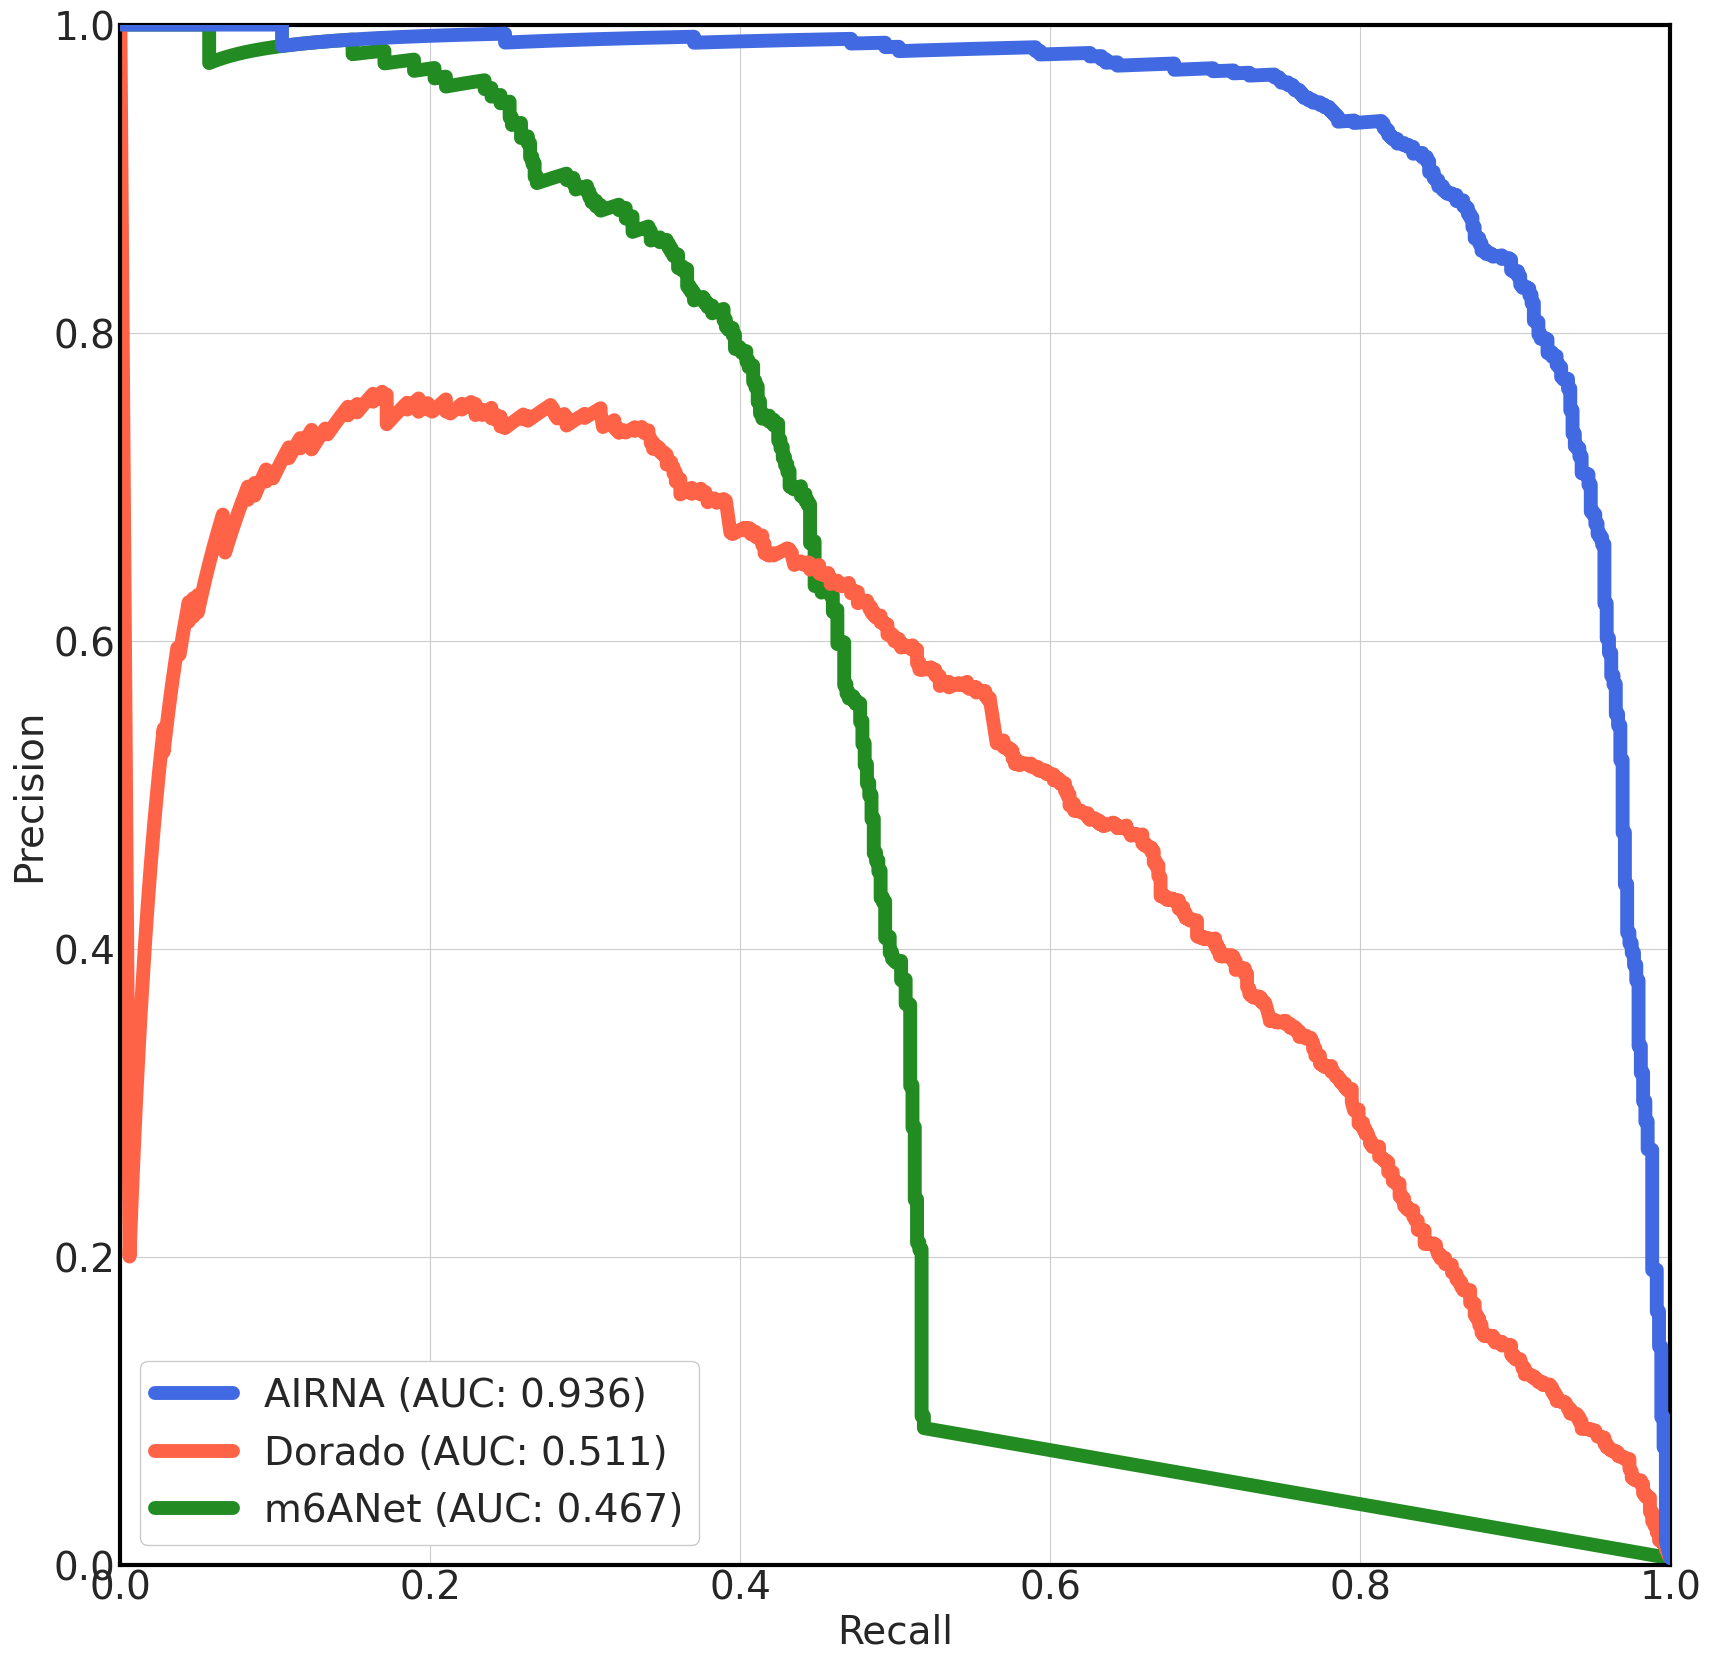

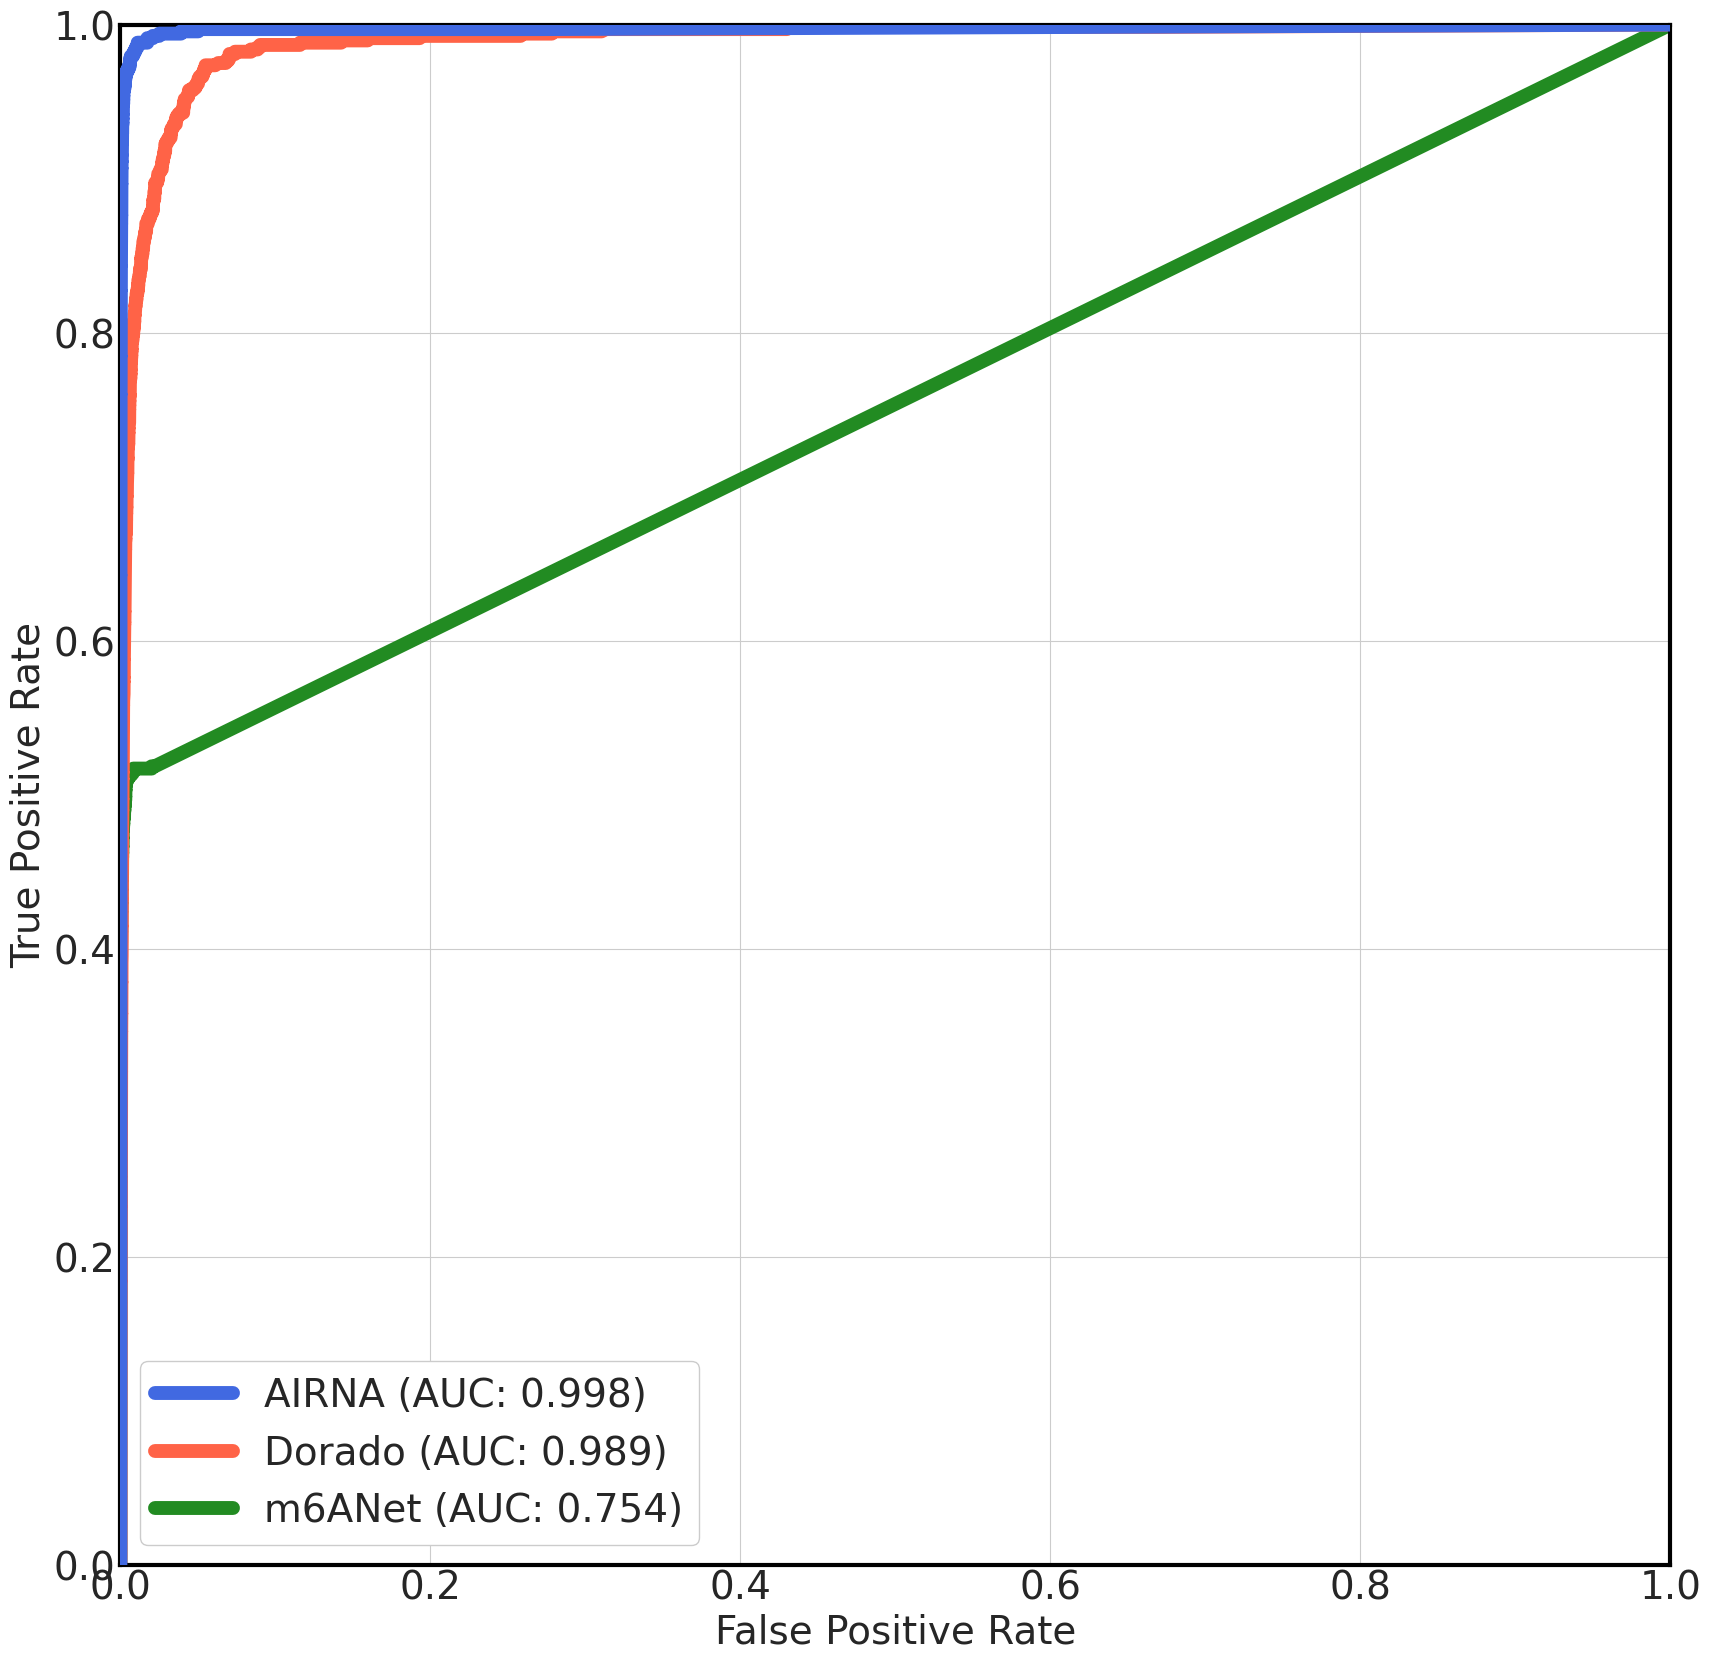

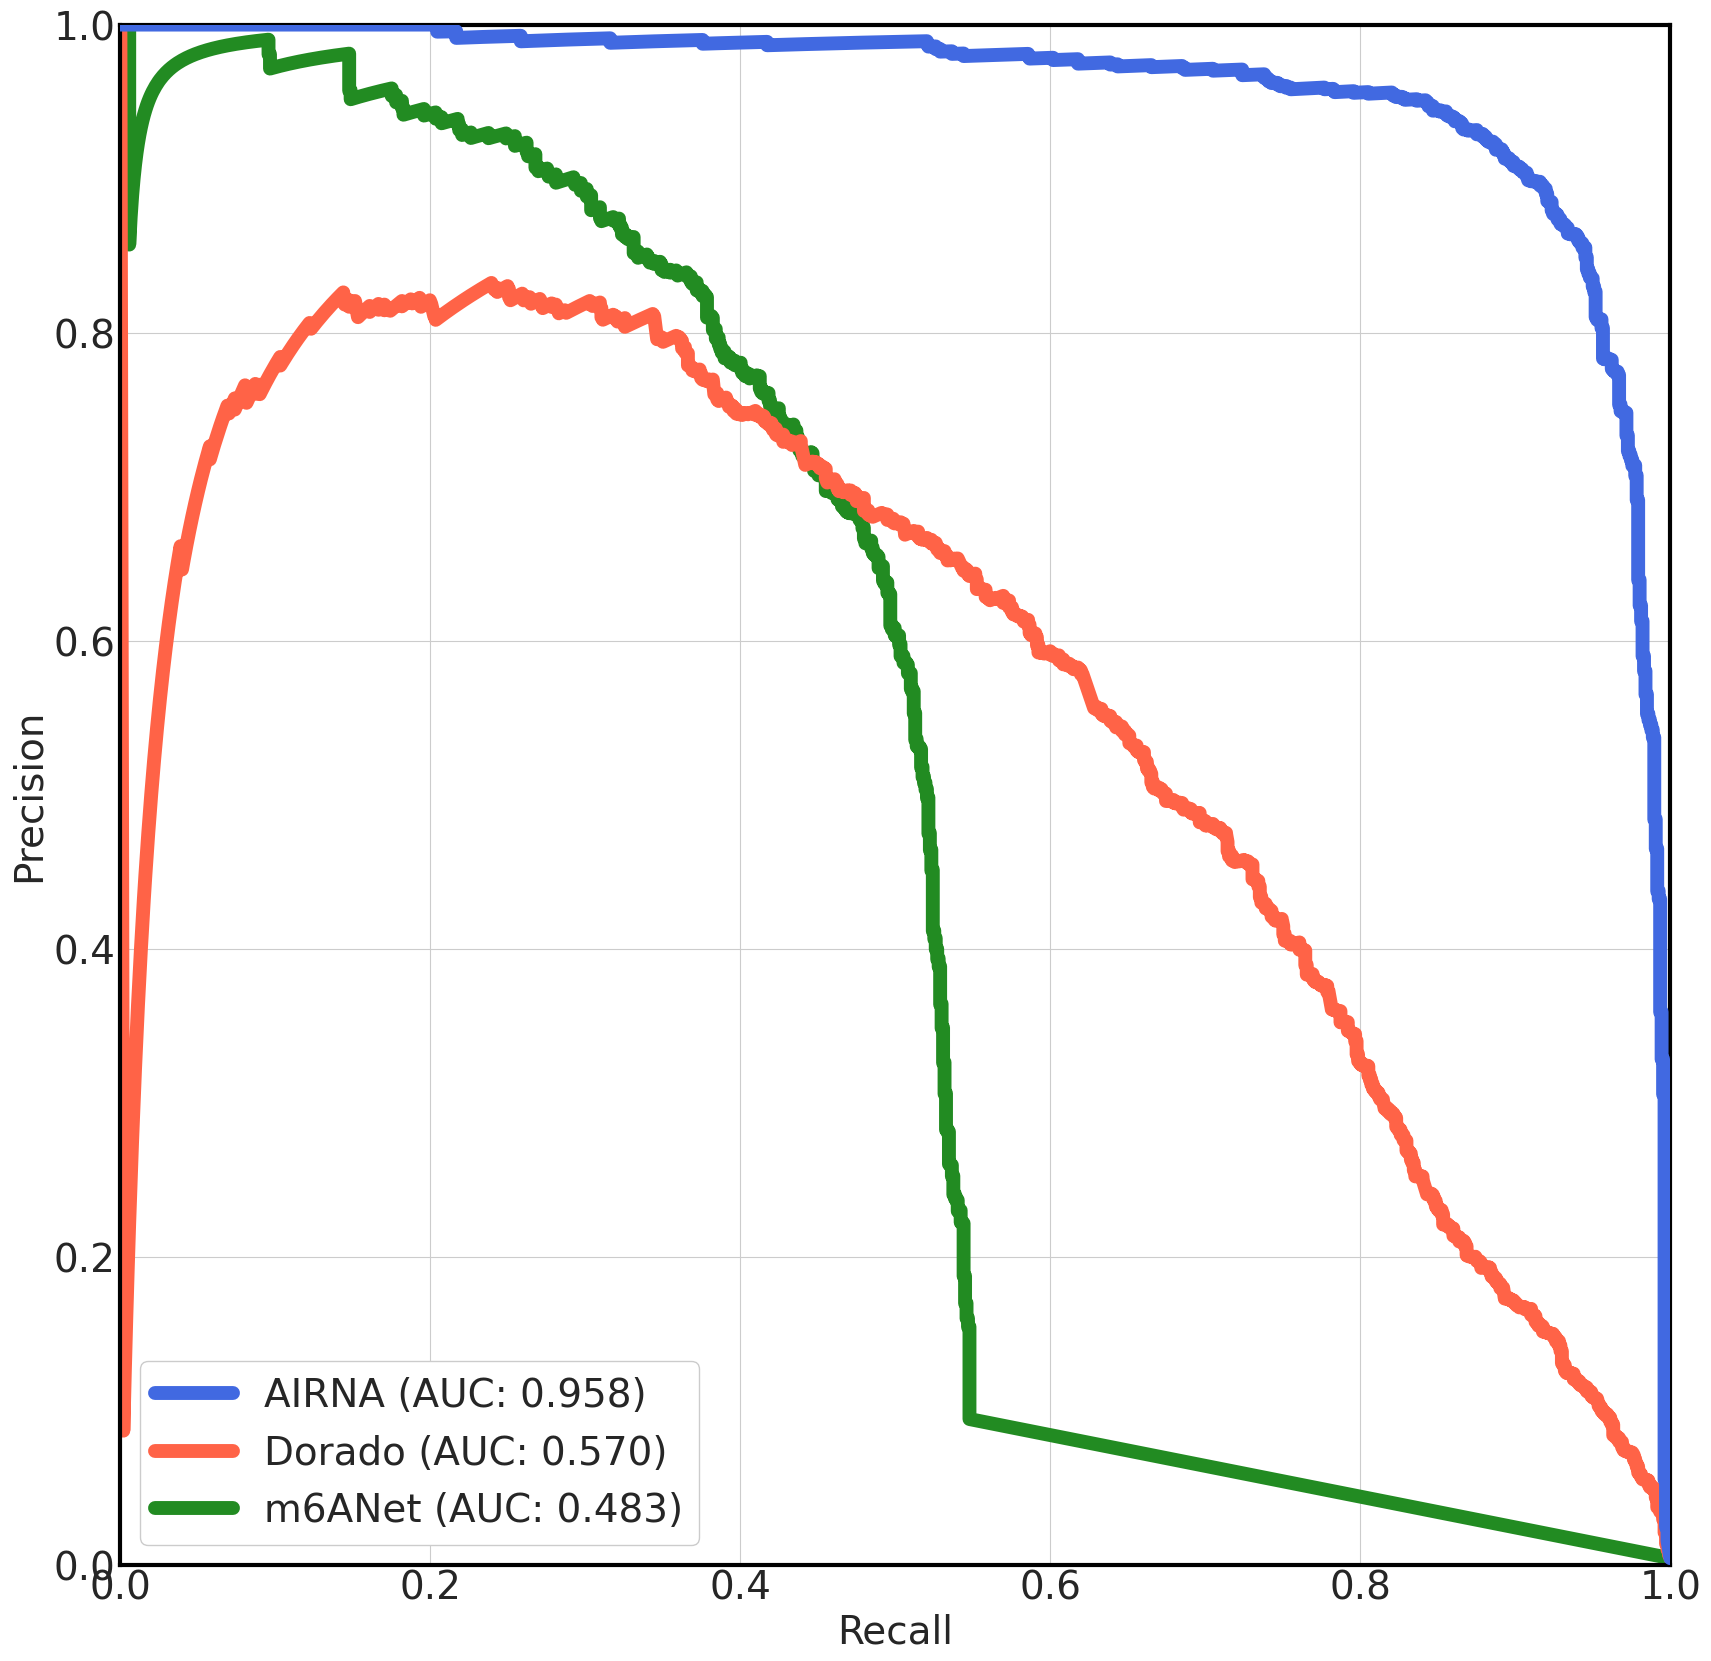

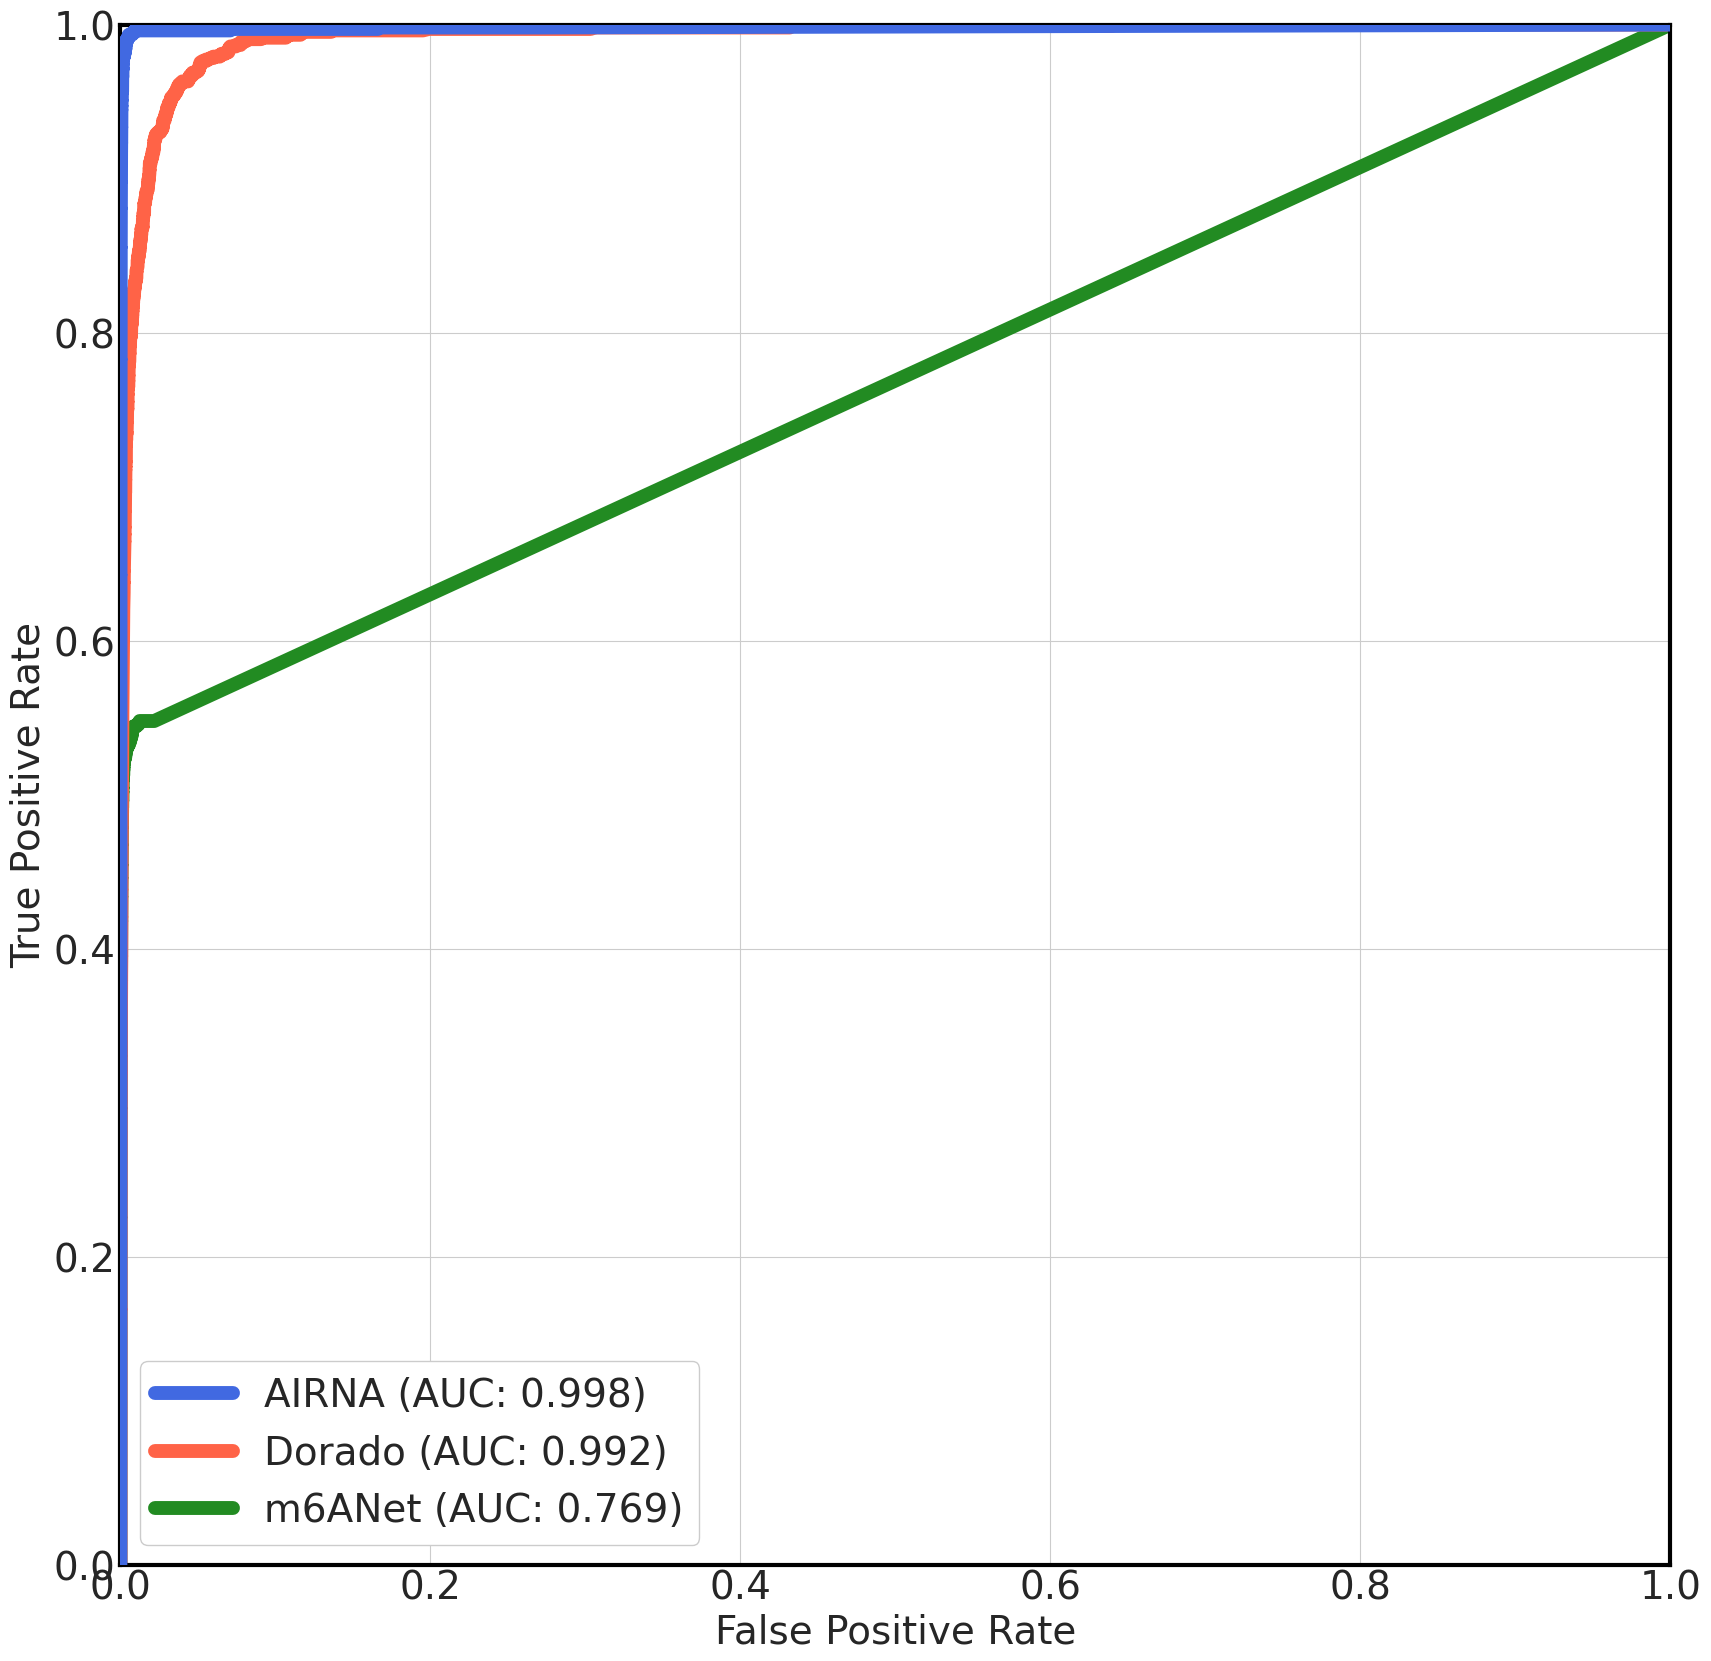

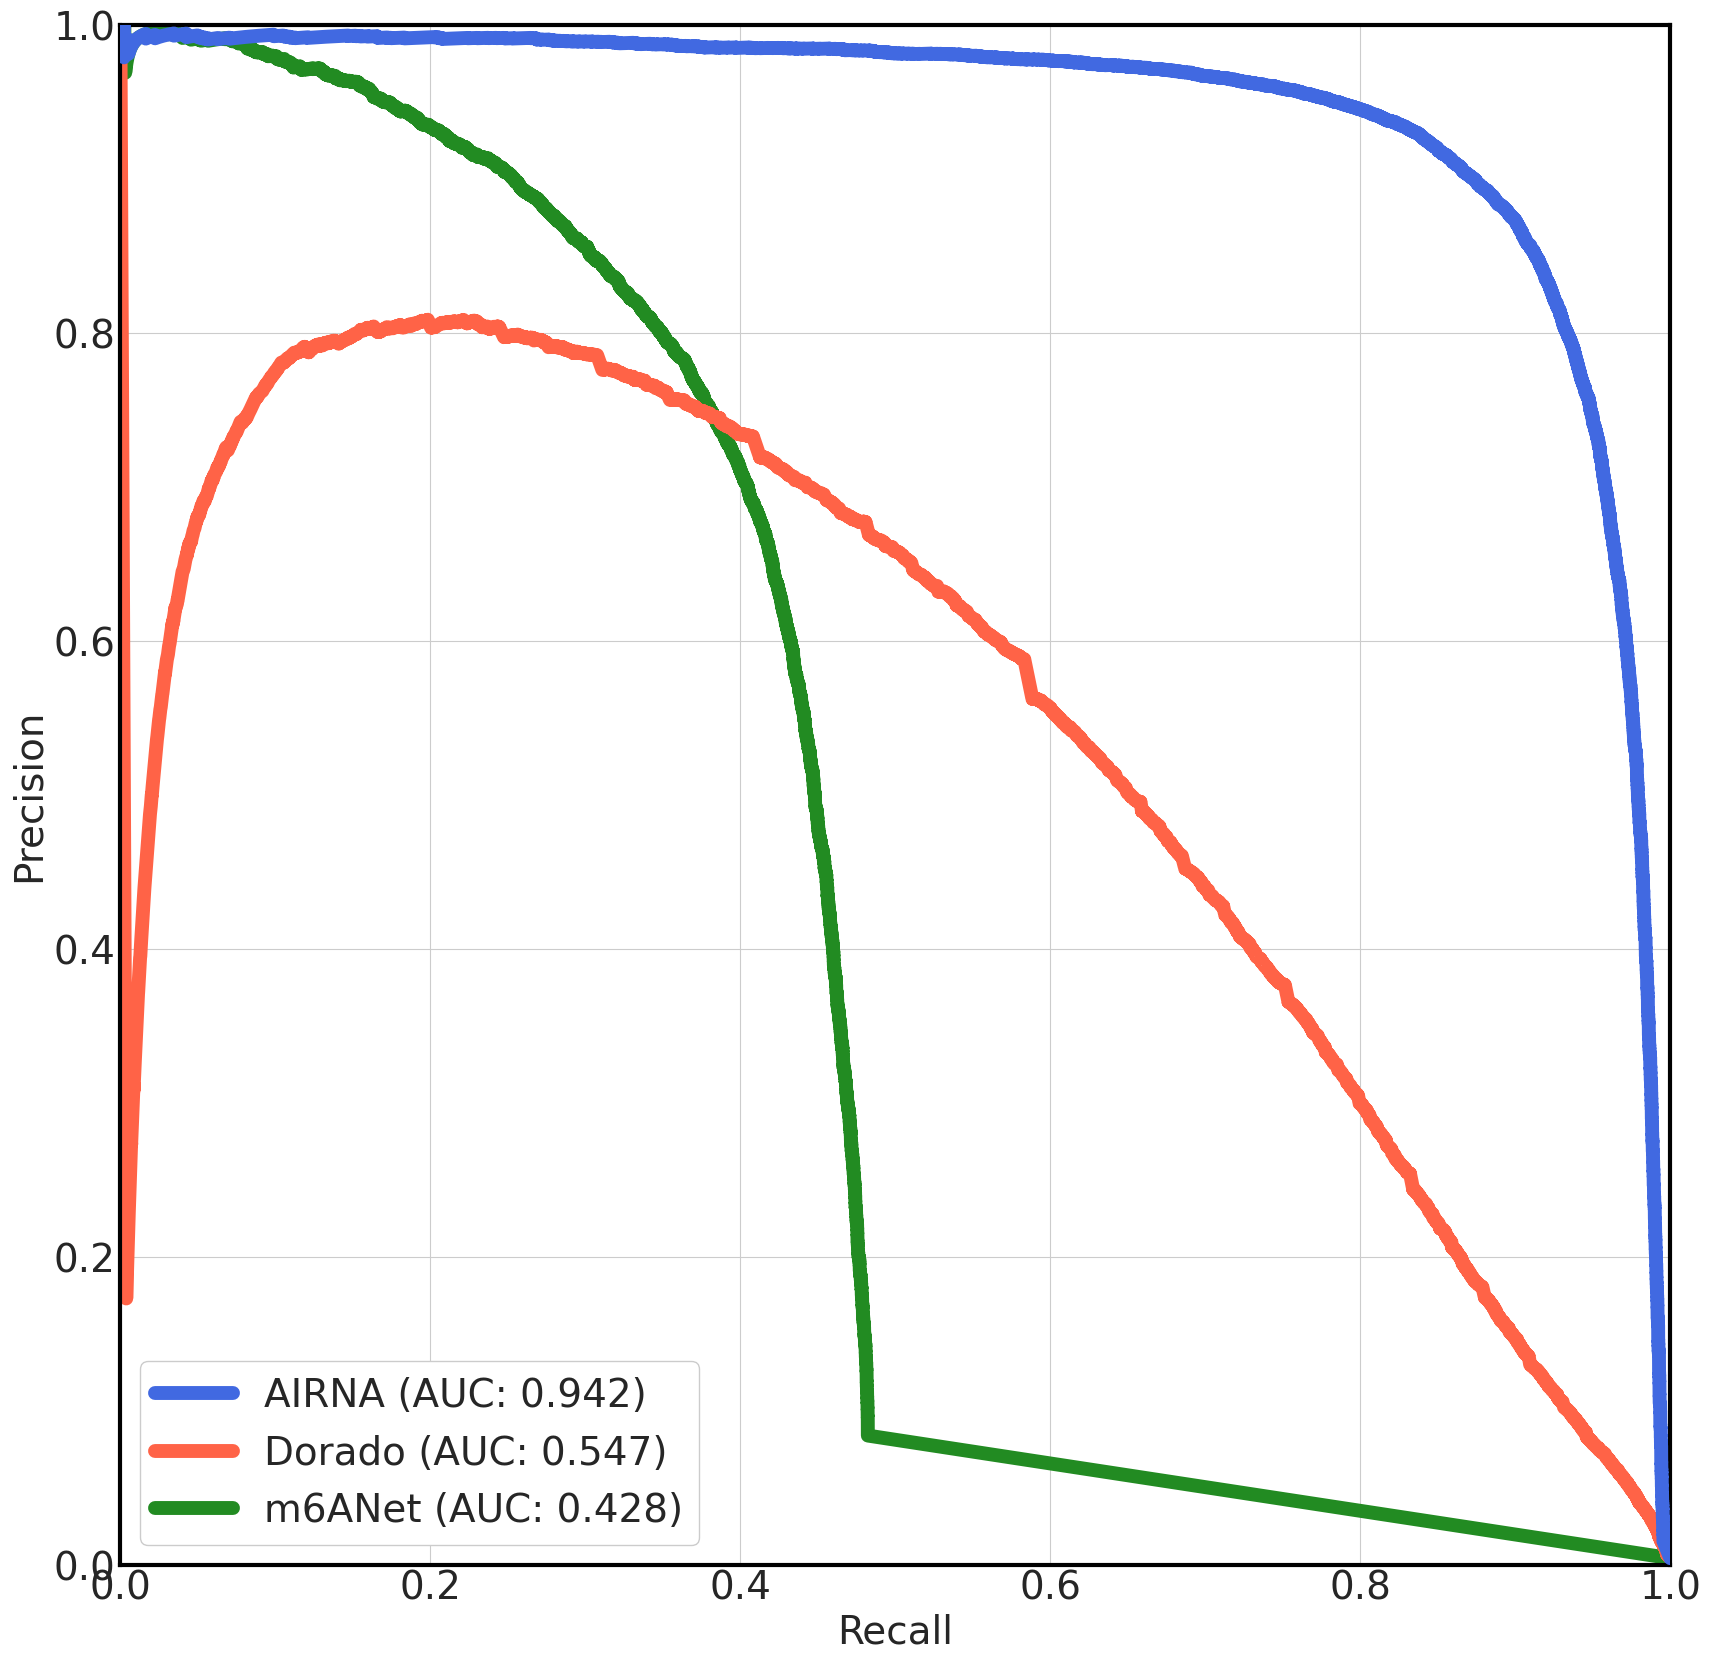

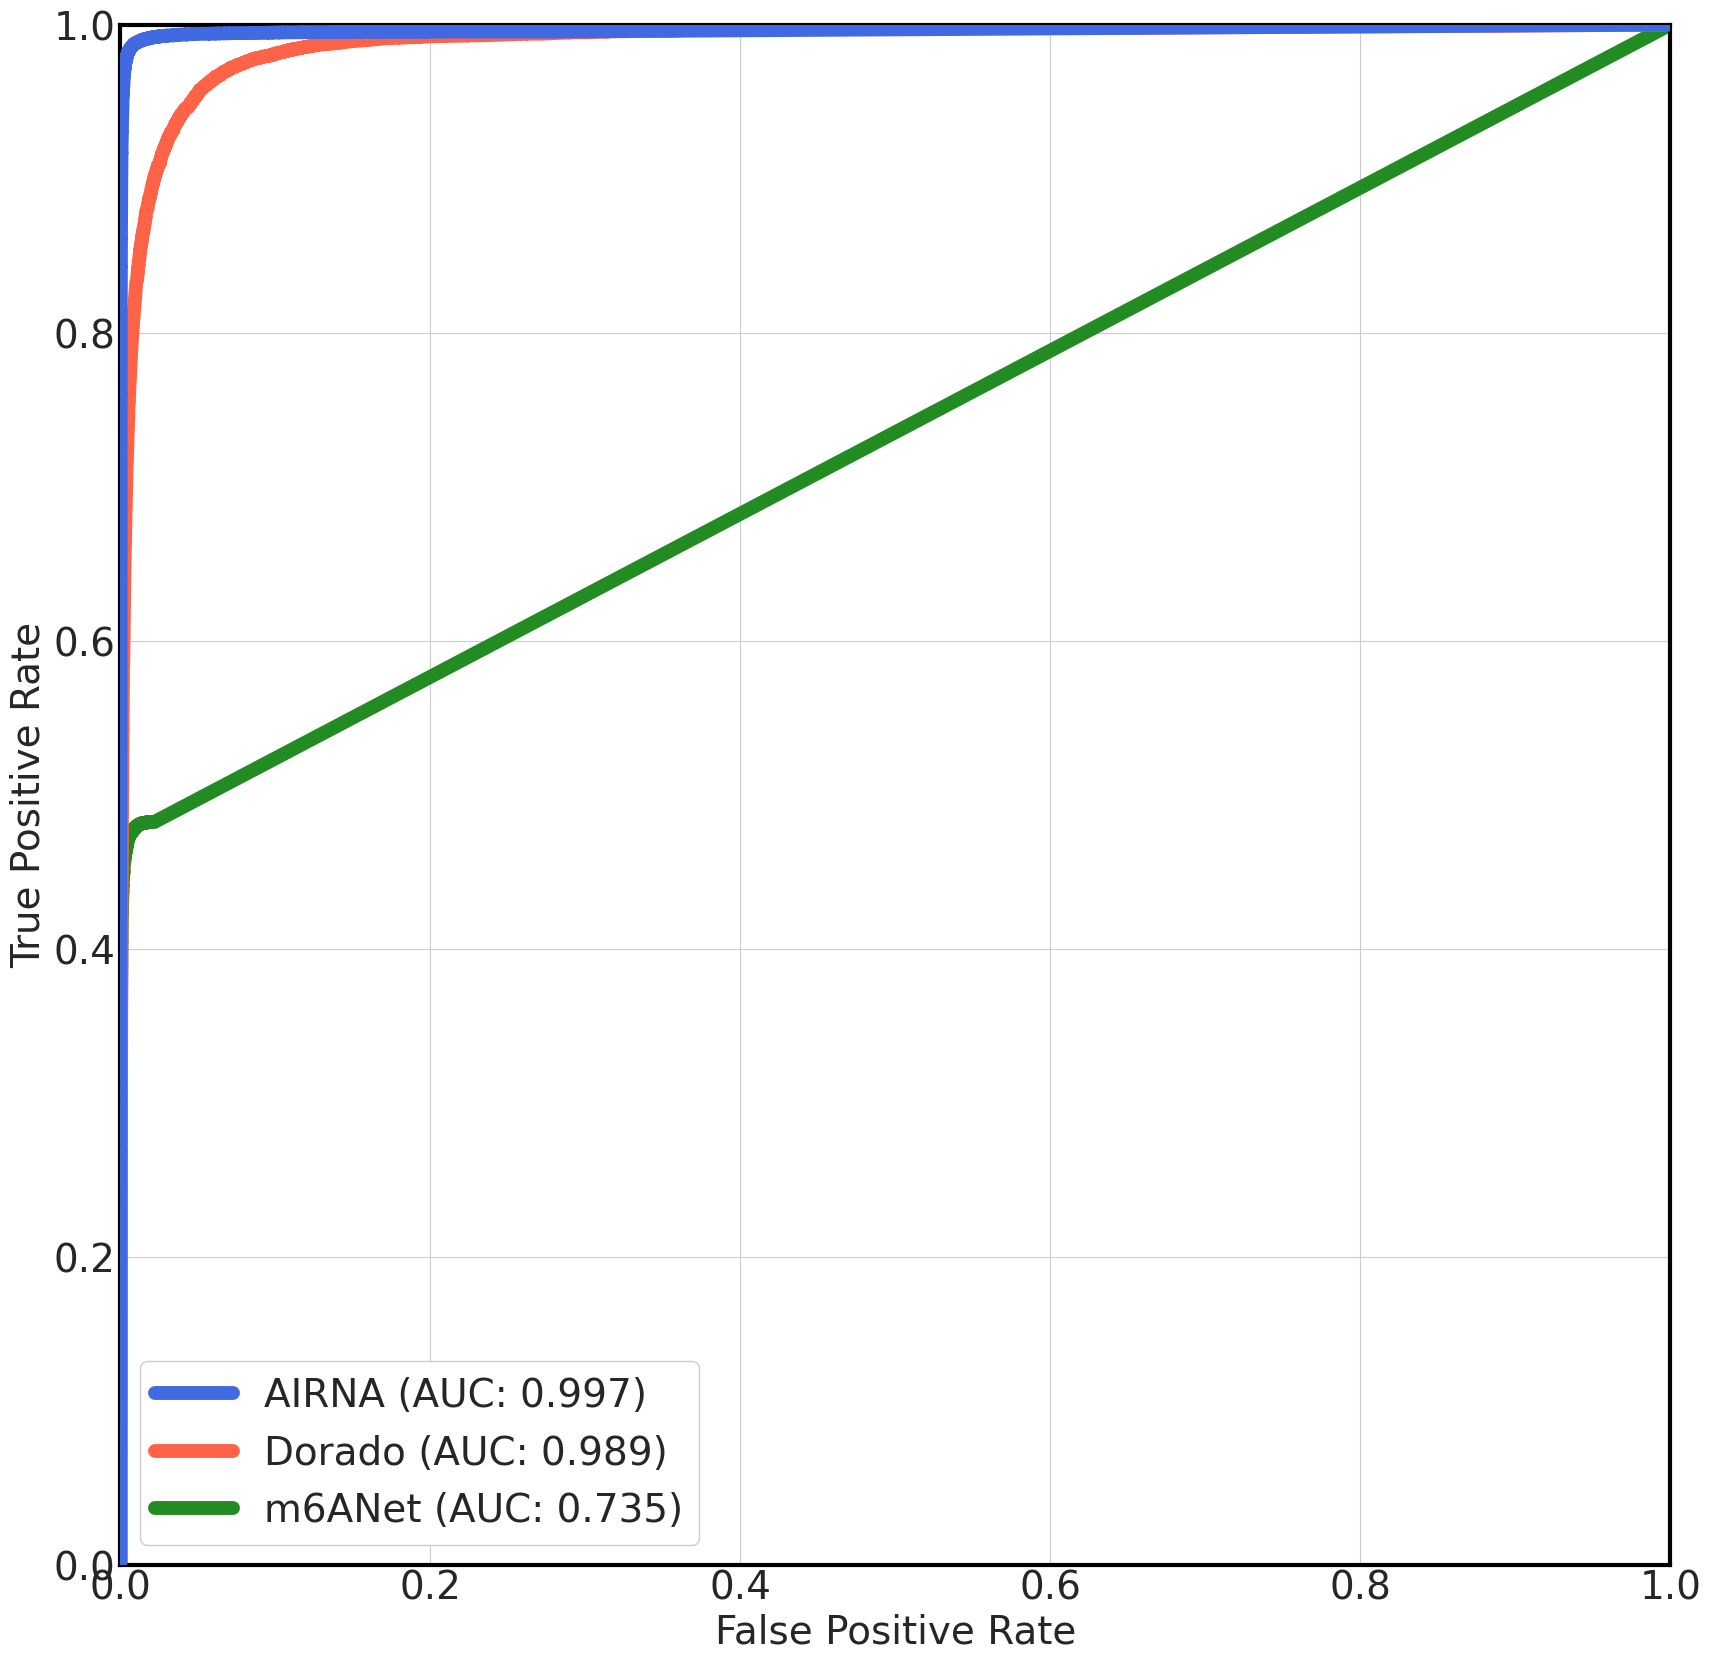

In [181]:
for k,v in cluster_benchmark_df_dict.items():
    run_benchmark(v, k)

In [105]:
print(size_dict)

{'cluster_1_10': 681, 'cluster_11_20': 1057, 'cluster_none': 19927}
